In [1]:
# visualize.ipynb - Cell 1
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make sure output folder exists
os.makedirs("data/processed", exist_ok=True)

# === IMPORTANT: exact 9 features (same order you used) ===
feature_names = [
    "EmpDepartment",
    "EmpJobRole",
    "EmpEnvironmentSatisfaction",
    "EmpLastSalaryHikePercent",
    "EmpWorkLifeBalance",
    "ExperienceYearsAtThisCompany",
    "ExperienceYearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager"
]

print("Feature names used for visualization (count={}):".format(len(feature_names)))
print(feature_names)


Feature names used for visualization (count=9):
['EmpDepartment', 'EmpJobRole', 'EmpEnvironmentSatisfaction', 'EmpLastSalaryHikePercent', 'EmpWorkLifeBalance', 'ExperienceYearsAtThisCompany', 'ExperienceYearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [2]:
# visualize.ipynb - Cell 2
# Load saved Random Forest model
model_path = "models/final_random_forest_model.joblib"
if not os.path.exists(model_path):
    raise FileNotFoundError(f"Model not found: {model_path}  -- run train_model.ipynb and save the model first.")

model = joblib.load(model_path)
print("Loaded model:", type(model).__name__)

# Load processed dataset (the same file you used for predictions)
df = pd.read_csv("data/processed/employee_perf_clean.csv")
print("Loaded processed data with shape:", df.shape)

# Select the features in exact order
missing = [c for c in feature_names if c not in df.columns]
if missing:
    raise ValueError("Missing features in data (fix preprocessing or feature list): " + str(missing))

X_vis = df[feature_names].copy()
print("X_vis shape:", X_vis.shape)
print("Dtypes before conversion:\n", X_vis.dtypes)

# Convert object / category columns to numeric codes (best-effort; consistent with prediction notebook)
for c in X_vis.columns:
    if X_vis[c].dtype == 'object' or str(X_vis[c].dtype).startswith('category'):
        X_vis[c] = X_vis[c].astype('category').cat.codes

# Ensure numeric dtype
X_vis = X_vis.apply(pd.to_numeric, errors='coerce')

# Fill any NaNs with medians (sensible fallback)
nan_cols = X_vis.columns[X_vis.isna().any()].tolist()
if nan_cols:
    for c in nan_cols:
        X_vis[c].fillna(X_vis[c].median(), inplace=True)
    print("Filled NaNs in columns:", nan_cols)

print("Dtypes after conversion:\n", X_vis.dtypes)


Loaded model: RandomForestClassifier
Loaded processed data with shape: (1200, 29)
X_vis shape: (1200, 9)
Dtypes before conversion:
 EmpDepartment                   int64
EmpJobRole                      int64
EmpEnvironmentSatisfaction      int64
EmpLastSalaryHikePercent        int64
EmpWorkLifeBalance              int64
ExperienceYearsAtThisCompany    int64
ExperienceYearsInCurrentRole    int64
YearsSinceLastPromotion         int64
YearsWithCurrManager            int64
dtype: object
Dtypes after conversion:
 EmpDepartment                   int64
EmpJobRole                      int64
EmpEnvironmentSatisfaction      int64
EmpLastSalaryHikePercent        int64
EmpWorkLifeBalance              int64
ExperienceYearsAtThisCompany    int64
ExperienceYearsInCurrentRole    int64
YearsSinceLastPromotion         int64
YearsWithCurrManager            int64
dtype: object


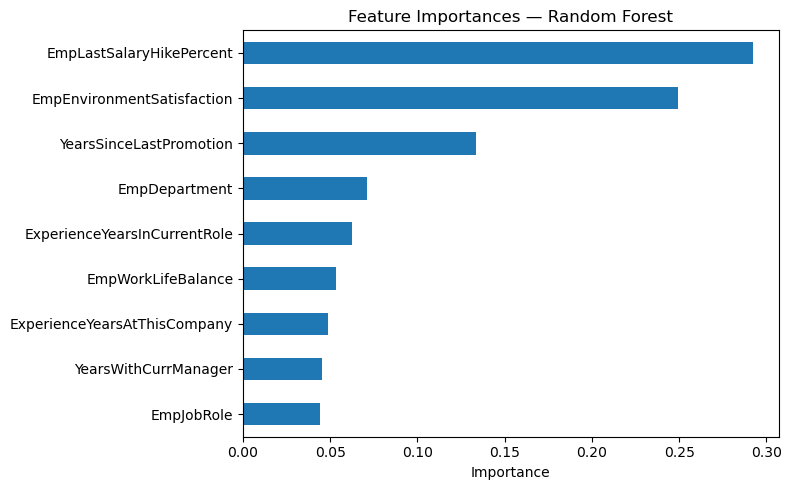

Saved feature importances to data/processed/feature_importances_barh.png and .csv

Top 3 features (by importance):
EmpLastSalaryHikePercent      0.292362
EmpEnvironmentSatisfaction    0.249270
YearsSinceLastPromotion       0.133319
dtype: float64


In [3]:
# visualize.ipynb - Cell 3
# Extract feature importances from RandomForest
if hasattr(model, "feature_importances_"):
    importances = model.feature_importances_
    fi = pd.Series(importances, index=feature_names).sort_values(ascending=True)  # ascending for horizontal bar
else:
    raise AttributeError("Model does not have feature_importances_. Are you sure this is a tree-based RF model?")

# Plot horizontal bar chart (top -> bottom)
plt.figure(figsize=(8,5))
fi.plot(kind='barh')
plt.title("Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("data/processed/feature_importances_barh.png", dpi=150)
plt.show()

# Save CSV of importances
fi.sort_values(ascending=False).to_csv("data/processed/feature_importances_sorted.csv", header=["importance"])
print("Saved feature importances to data/processed/feature_importances_barh.png and .csv")

# Print top 3
top3 = fi.sort_values(ascending=False).head(3)
print("\nTop 3 features (by importance):")
print(top3)


### Top 3 Factors Affecting Employee Performance

1. **EmpLastSalaryHikePercent** – Employees receiving higher salary hikes show better performance.
2. **EmpEnvironmentSatisfaction** – A positive work environment strongly increases performance.
3. **YearsSinceLastPromotion** – Employees promoted recently tend to perform better.

These factors indicate that compensation, environment satisfaction, and promotion cycle directly influence performance scores.
